C:\Users\Satvik Pandey\AppData\Local\Temp\ipykernel_24684\2277852061.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imread('peppers.jpeg') / 255.0


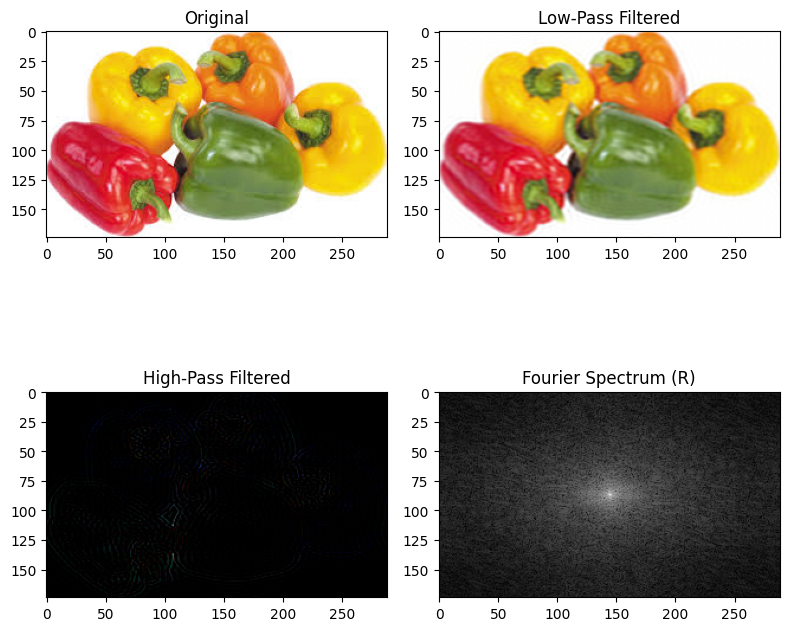

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread

img = imread('peppers.jpeg') / 255.0

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

M, N = R.shape
X, Y = np.meshgrid(np.arange(1, N+1), np.arange(1, M+1))

cx = N//2
cy = M//2

D0 = 50
D = np.sqrt((X - cx)**2 + (Y - cy)**2)

LPF = (D <= D0).astype(float)
HPF = (D > D0).astype(float)

FR = np.fft.fftshift(np.fft.fft2(R))
FG = np.fft.fftshift(np.fft.fft2(G))
FB = np.fft.fftshift(np.fft.fft2(B))

R_LPF = FR * LPF
G_LPF = FG * LPF
B_LPF = FB * LPF

R_HPF = FR * HPF
G_HPF = FG * HPF
B_HPF = FB * HPF

r_lpf_ifft = np.fft.ifft2(np.fft.ifftshift(R_LPF))
g_lpf_ifft = np.fft.ifft2(np.fft.ifftshift(G_LPF))
b_lpf_ifft = np.fft.ifft2(np.fft.ifftshift(B_LPF))

r_hpf_ifft = np.fft.ifft2(np.fft.ifftshift(R_HPF))
g_hpf_ifft = np.fft.ifft2(np.fft.ifftshift(G_HPF))
b_hpf_ifft = np.fft.ifft2(np.fft.ifftshift(B_HPF))

LPF_img = np.stack([np.real(r_lpf_ifft), np.real(g_lpf_ifft), np.real(b_lpf_ifft)], axis=2)
HPF_img = np.stack([np.real(r_hpf_ifft), np.real(g_hpf_ifft), np.real(b_hpf_ifft)], axis=2)

LPF_img = np.clip(LPF_img, 0, 1)
HPF_img = np.clip(HPF_img, 0, 1)

plt.figure(figsize=(8,8))
plt.subplot(2,2,1); plt.imshow(img); plt.title('Original')
plt.subplot(2,2,2); plt.imshow(LPF_img); plt.title('Low-Pass Filtered')
plt.subplot(2,2,3); plt.imshow(HPF_img); plt.title('High-Pass Filtered')
plt.subplot(2,2,4); plt.imshow(np.log(1+np.abs(FR)), cmap='gray'); plt.title('Fourier Spectrum (R)')
plt.tight_layout()
plt.show()
